In [16]:
#Importation des bibliothèques

import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import numpy as np
import os
import requests
import py7zr
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import shutil
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt



l’indice d’humidité des sols SWI est défini comme suit :

SWI = (W - Wwilt) / (Wfc - Wwilt)

où W est le contenu intégré en eau du sol, Wwilt le contenu en eau au point de flétrissement et Wfc le contenu en eau du sol à la capacité au champ.

Le SWI vaut 0 pour un sol très sec (et peut être négatif pour un sol extrêmement sec), il atteint la valeur de 1 pour un sol à capacité au champ, dépasse 1 pour des sols très humides, et est borné à une valeur correspondant à la saturation (dépendante de la composition du sol présent en chaque point de grille).  

 

In [4]:
# Données SWI uniforme
fp = Path("data") / "processed" / "jointure_meteo_swi_argile_nearest.gpkg.zip"
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
data= gpd.read_file(fp)

In [ ]:
### Affichage des données de SWI mensuel ###
data.head()

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry
0,3827,773980,6713410,1960-12-01,0.982,5.7,59.2,1.941935,3.132258,4.049000,...,0.370645,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.0,POINT (723999.802 2280998.23)
1,3826,765986,6713478,1960-12-01,0.977,4.8,58.9,2.216129,3.254839,4.104935,...,0.351065,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.0,POINT (715999.436 2280998.385)
2,3825,757993,6713546,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.334355,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.0,POINT (708000.072 2280998.598)
3,3824,749999,6713614,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.324452,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.0,POINT (699999.708 2280998.852)
4,5323,717146,6609971,1960-09-01,0.449,0.0,73.6,13.356667,1.530000,8.058967,...,0.263533,0.000000,2.3,24.0,1960,Moyen,2.0,3,0.0,POINT (667998.94 2176998.552)


In [ ]:
#Analyse des valeurs manquantes
missing_table = pd.swiFrame({
    "Variable": data.columns,
    "Missing %": (data.isna().mean() * 100)
})

# On filtre les variables avec des NA
missing_table = missing_table[missing_table["Missing %"] > 0]

# Tri décroissant
missing_table = missing_table.sort_values("Missing %", ascending=False)

# Affichage
if missing_table.empty:
    print("Aucune valeur manquante dans le swiset ")
else:
    display(missing_table)

Aucune valeur manquante dans le dataset 


In [7]:
# Création d’un tableau lisible des types de variables
dtypes_table = pd.DataFrame({
    "Variable": data.columns,
    "Type": data.dtypes.values
})

display(dtypes_table)

,Variable,Type
0,NUMERO,int64
1,LAMBX,int64
2,LAMBY,int64
3,DATE,datetime64[ms]
4,SWI_UNIF_MENS,float64
5,PRENEI,float64
6,PRELIQ,float64
7,T,float64
8,FF,float64
9,Q,float64


### Statistiques descriptives

In [14]:
# --- Préparation des données ---
# On sélectionne uniquement les colonnes utiles :
# - DATE : pour l'analyse temporelle
# - SWI_UNIF_MENS : la variable d'intérêt
eda = data[["DATE", "SWI_UNIF_MENS"]].copy()

# Conversion de DATE en vrai format datetime
# errors="coerce" transforme les valeurs invalides en NaT
eda["DATE"] = pd.to_datetime(eda["DATE"], errors="coerce")

# Conversion de SWI_UNIF_MENS en numérique
# Les valeurs non convertibles deviennent NaN
eda["SWI_UNIF_MENS"] = pd.to_numeric(eda["SWI_UNIF_MENS"], errors="coerce")

# Suppression des lignes où DATE ou SWI_UNIF_MENS sont manquants
eda = eda.dropna(subset=["DATE", "SWI_UNIF_MENS"])

# On isole la série SWI pour simplifier les calculs
swi = eda["SWI_UNIF_MENS"]

# --- Statistiques descriptives ---
# Calcul des statistiques descriptives classiques
# + certains quantiles utiles pour analyser la distribution
desc = swi.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

# Calcul de l'écart interquartile (IQR = Q3 - Q1)
iqr = desc["75%"] - desc["25%"]

# Bornes classiques de détection des valeurs aberrantes selon la règle IQR
lower = desc["25%"] - 1.5 * iqr
upper = desc["75%"] + 1.5 * iqr

# Taux de valeurs aberrantes : proportion de points hors des bornes IQR
outlier_rate = ((swi < lower) | (swi > upper)).mean() * 100

# Construction d'un tableau récapitulatif des statistiques principales
stats_table = pd.Series(
    {
        "count": swi.count(),                  # nombre d'observations
        "mean": swi.mean(),                    # moyenne
        "median": swi.median(),                # médiane
        "std": swi.std(),                      # écart-type
        "variance": swi.var(),                 # variance
        "min": swi.min(),                      # minimum
        "max": swi.max(),                      # maximum
        "q01": desc["1%"],                     # 1er centile
        "q05": desc["5%"],                     # 5e centile
        "q25": desc["25%"],                    # 1er quartile
        "q50": desc["50%"],                    # médiane
        "q75": desc["75%"],                    # 3e quartile
        "q95": desc["95%"],                    # 95e centile
        "q99": desc["99%"],                    # 99e centile
        "IQR": iqr,                            # écart interquartile
        "skewness": swi.skew(),                # asymétrie de la distribution
        "kurtosis_fisher": swi.kurt(),         # kurtosis de Fisher : 0 pour une loi normale
        "kurtosis_pearson": swi.kurt() + 3,    # kurtosis de Pearson : 3 pour une loi normale
        "outlier_rate_IQR_%": outlier_rate,    # % de valeurs aberrantes
    },
    name="SWI_UNIF_MENS"
)

# Affichage du tableau statistique
display(stats_table.to_frame())



,SWI_UNIF_MENS
count,7.005180e+06
mean,6.137139e-01
median,6.620000e-01
std,3.272674e-01
variance,1.071039e-01
min,-5.700000e-02
max,1.542000e+00
q01,-6.000000e-03
q05,6.400000e-02
q25,3.250000e-01


La distribution du SWI apparaît quasi symétrique (skewness = -0,27), traduisant une asymétrie faible.
Le kurtosis négatif (Fisher = -1,17) met en évidence une distribution platykurtique, caractérisée par une forme plus aplatie et des queues plus légères que celles d’une loi normale.
Ce profil est cohérent avec la nature bornée du SWI (comprise entre 0 et 1), qui limite intrinsèquement l’apparition de valeurs extrêmes.
Par ailleurs, le taux d’outliers basé sur l’IQR est nul (0 %), ce qui confirme l’absence de valeurs aberrantes selon le critère de Tukey. Ce résultat est en accord avec le kurtosis observé, reflétant une distribution à queues fines.

## Marginal Distribution

/tmp/ipykernel_123029/2625429331.py:97: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/python/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


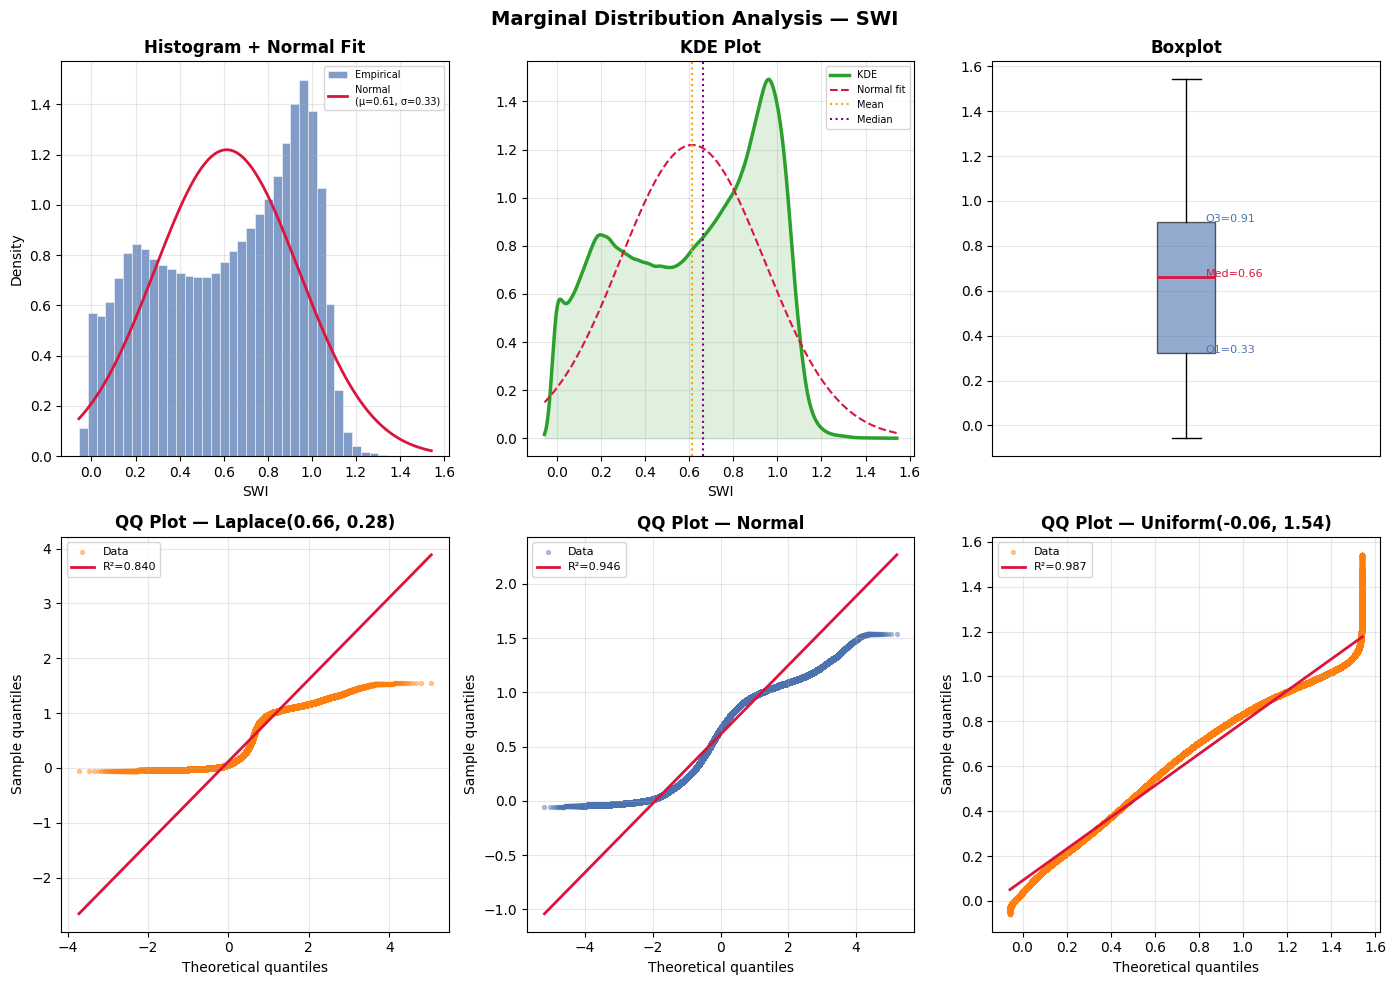


📊 Goodness of fit — R² des QQ plots
  Normal      : R² = 0.9459
  Laplace        : R² = 0.8397
  Uniform     : R² = 0.9869

  → Meilleur fit : Uniform


In [ ]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Marginal Distribution Analysis — SWI", fontsize=14, fontweight="bold")

# ── 2.1 Histogram ──────────────────────────────────────────
ax1 = fig.add_subplot(231)
ax1.hist(swi, bins=40, density=True, color="#4C72B0", alpha=0.7,
         edgecolor="white", linewidth=0.5, label="Empirical")

mu, sigma = stats.norm.fit(swi)
x_range = np.linspace(swi.min(), swi.max(), 200)
ax1.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
         color="crimson", lw=2, label=f"Normal\n(μ={mu:.2f}, σ={sigma:.2f})")
ax1.set_title("Histogram + Normal Fit", fontweight="bold")
ax1.set_xlabel("SWI")
ax1.set_ylabel("Density")
ax1.legend(fontsize=7)
ax1.grid(alpha=0.3)

# ── 2.2 KDE ────────────────────────────────────────────────
ax2 = fig.add_subplot(232)
kde = stats.gaussian_kde(swi)
x_kde = np.linspace(swi.min(), swi.max(), 300)
ax2.plot(x_kde, kde(x_kde), color="#2ca02c", lw=2.5, label="KDE")
ax2.fill_between(x_kde, kde(x_kde), alpha=0.15, color="#2ca02c")
ax2.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
         color="crimson", lw=1.5, linestyle="--", label="Normal fit")
ax2.axvline(swi.mean(),   color="orange", lw=1.5, linestyle=":", label="Mean")
ax2.axvline(swi.median(), color="purple", lw=1.5, linestyle=":", label="Median")
ax2.set_title("KDE Plot", fontweight="bold")
ax2.set_xlabel("SWI")
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

# ── 2.3 Boxplot ────────────────────────────────────────────
ax3 = fig.add_subplot(233)
bp = ax3.boxplot(swi, vert=True, patch_artist=True,
                 boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                 medianprops=dict(color="crimson", linewidth=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="orange"))
q1, med, q3 = np.percentile(swi, [25, 50, 75])
ax3.annotate(f"Q3={q3:.2f}",     xy=(1.05, q3),  fontsize=8, color="#4C72B0")
ax3.annotate(f"Med={med:.2f}",   xy=(1.05, med), fontsize=8, color="crimson")
ax3.annotate(f"Q1={q1:.2f}",     xy=(1.05, q1),  fontsize=8, color="#4C72B0")
ax3.set_title("Boxplot", fontweight="bold")
ax3.set_xticks([])
ax3.grid(alpha=0.3, axis="y")

# ── 2.4 QQ Plot — Laplace ────────────────────────────────
ax6 = fig.add_subplot(234)

# Fit de la loi de Laplace
loc_l, scale_l = stats.laplace.fit(swi)

(osm_l, osr_l), (slope_l, intercept_l, r_l) = stats.probplot(
    swi,
    dist=stats.laplace,
    sparams=(loc_l, scale_l)
)

ax6.scatter(osm_l, osr_l, color="#ff7f0e", alpha=0.4, s=8, label="Data")
ax6.plot(osm_l, slope_l * np.array(osm_l) + intercept_l,
         color="crimson", lw=2, label=f"R²={r_l**2:.3f}")

ax6.set_title(f"QQ Plot — Laplace({loc_l:.2f}, {scale_l:.2f})", fontweight="bold")
ax6.set_xlabel("Theoretical quantiles")
ax6.set_ylabel("Sample quantiles")
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

# ── 2.5 QQ Plot — Normal ───────────────────────────────────
ax4 = fig.add_subplot(235)
(osm, osr), (slope, intercept, r) = stats.probplot(swi, dist="norm")
ax4.scatter(osm, osr, color="#4C72B0", alpha=0.4, s=8, label="Data")
ax4.plot(osm, slope * np.array(osm) + intercept,
         color="crimson", lw=2, label=f"R²={r**2:.3f}")
ax4.set_title("QQ Plot — Normal", fontweight="bold")
ax4.set_xlabel("Theoretical quantiles")
ax4.set_ylabel("Sample quantiles")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ── 2.6 QQ Plot — Uniforme ────────────────────────────────
ax6 = fig.add_subplot(236)
loc_u, scale_u = stats.uniform.fit(swi)
(osm_u, osr_u), (slope_u, intercept_u, r_u) = stats.probplot(
    swi, dist=stats.uniform, sparams=(loc_u, scale_u)
)
ax6.scatter(osm_u, osr_u, color="#ff7f0e", alpha=0.4, s=8, label="Data")
ax6.plot(osm_u, slope_u * np.array(osm_u) + intercept_u,
         color="crimson", lw=2, label=f"R²={r_u**2:.3f}")
ax6.set_title(f"QQ Plot — Uniform({loc_u:.2f}, {loc_u+scale_u:.2f})", fontweight="bold")
ax6.set_xlabel("Theoretical quantiles")
ax6.set_ylabel("Sample quantiles")
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Comparaison des fits ───────────────────────────────────
print("\n Goodness of fit — R² des QQ plots")
print(f"  Normal      : R² = {r**2:.4f}")
print(f"  Laplace        : R² = {r_l**2:.4f}")
print(f"  Uniform     : R² = {r_u**2:.4f}")
print(f"\n  → Meilleur fit : {'Normal' if r**2 > r_l**2 and r**2 > r_u**2 else 'Laplace' if r_l**2 > r_u**2 else 'Uniform'}")

In [ ]:
# --- Tests de normalité (sur échantillon pour performance) ---
# la série est très grande, on limite à 200 000 observations
sample_n = min(200_000, len(swi))
sample = swi.sample(sample_n, random_state=42)

# Test de normalité de D’Agostino et Pearson
# Il teste si asymétrie + kurtosis sont compatibles avec une loi normale
k2_stat, k2_p = stats.normaltest(sample)

# Test de Jarque-Bera
# Basé lui aussi sur skewness et kurtosis
jb_stat, jb_p = stats.jarque_bera(sample)

# Le test de Shapiro-Wilk est plus coûteux et recommandé sur petits échantillons
# On prend donc au maximum 5000 valeurs
shapiro_sample = sample.sample(min(5000, len(sample)), random_state=42)
sh_stat, sh_p = stats.shapiro(shapiro_sample)

# Tableau récapitulatif des tests de normalité
normality = pd.DataFrame(
    {
        "test": ["D’Agostino K²", "Jarque-Bera", "Shapiro-Wilk"],
        "statistique": [k2_stat, jb_stat, sh_stat],
        "p_value": [k2_p, jb_p, sh_p],
    }
)

# Affichage des résultats
display(normality)

,test,statistique,p_value
0,D’Agostino K²,138850.894926,0.000000e+00
1,Jarque-Bera,13808.250642,0.000000e+00
2,Shapiro-Wilk,0.945199,1.254962e-39


Les trois tests de normalité (D’Agostino K², Jarque–Bera et Shapiro–Wilk) donnent tous des p-values extrêmement proches de zéro, ce qui conduit à rejeter très fortement l’hypothèse de normalité des données.
 Cela signifie que la distribution étudiée s’écarte clairement d’une loi normale.

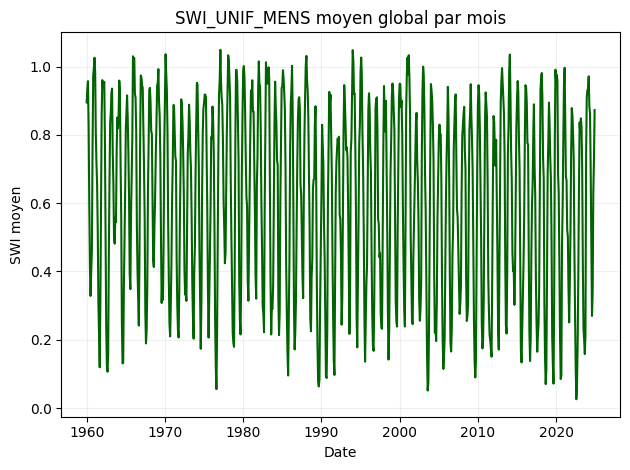

Text(0.5, 1.0, 'Saisonnalité de SWI_UNIF_MENS par mois')

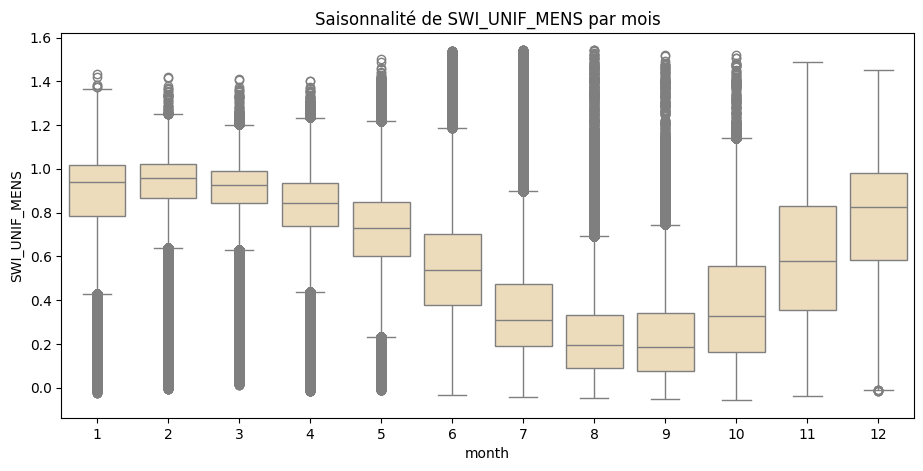

In [31]:

# Série temporelle moyenne mensuelle globale
# On agrège toutes les observations par mois et on prend la moyenne
swi_monthly_global = data.groupby(pd.Grouper(key="DATE", freq="MS"))["SWI_UNIF_MENS"].mean()
# Tracé de l'évolution temporelle moyenne mensuelle
plt.plot(swi_monthly_global.index, swi_monthly_global.values, color="darkgreen", linewidth=1.5)
plt.title("SWI_UNIF_MENS moyen global par mois")
plt.xlabel("Date")
plt.ylabel("SWI moyen")
plt.grid(alpha=0.2)


plt.tight_layout()
plt.show()

# --- Saisonnalité (mois) ---
# Création d'une variable mois à partir de la date
data["month"] = data["DATE"].dt.month

# Boxplot par mois pour étudier la saisonnalité du SWI
# On compare la distribution du SWI entre janvier, février, etc.
plt.figure(figsize=(11, 5))
sns.boxplot(data=data, x="month", y="SWI_UNIF_MENS", color="wheat")
plt.title("Saisonnalité de SWI_UNIF_MENS par mois")

| Nom du champ | Descriptif                                                                                                                     | Unité   | Précision |
|--------------|-------------------------------------------------------------------------------------------------------------------------------|---------|-----------|
| DATE         | Date de la mesure                                                                                                             | AAAAMMJJ|           |
| PRENEI       | Précipitations solides, cumul quotidien ]06UTC-06UTC]                                                                        | mm      | 1/10      |
| PRELIQ       | Précipitations liquides, cumul quotidien ]06UTC-06UTC]                                                                       | mm      | 1/10      |
| T            | Température moyenne quotidienne ]00UTC-00UTC]                                                                                | °C      | 1/10      |
| FF           | Vent moyen quotidien ]00UTC-00UTC]                                                                                           | m/s     | 1/10      |
| Q            | Humidité spécifique moyenne quotidienne ]00UTC-00UTC]                                                                        | g/kg    |           |
| DLI          | Rayonnement atmosphérique, cumul quotidien ]00UTC-00UTC]                                                                     | J/cm²   |           |
| SSI          | Rayonnement visible, cumul quotidien ]00UTC-00UTC]                                                                           | J/cm²   |           |
| HU           | Humidité relative moyenne quotidienne ]00UTC-00UTC]                                                                          | %       |           |
| EVAP         | Evapotranspiration totale, cumul quotidien ]06UTC-06UTC]                                                                     | mm      | 1/10      |
| ETP          | Evapotranspiration potentielle (formule de Penman-Monteith)                                                                 | mm      | 1/10      |
| PE           | Pluies efficaces, cumul quotidien ]06UTC-06UTC]                                                                              | mm      | 1/10      |
| SWI          | Indice d'humidité des sols, moyenne quotidienne [06UTC-06UTC]                                                                | %       |           |
| SSWI_10J     | Indice de sécheresse de l’humidité des sols intégré sur 10 jours (jour J et 9 jours précédents)                             | -       |           |
| DRAINC       | Drainage, cumul quotidien ]06UTC-06UTC]                                                                                      | mm      | 1/10      |
| RUNC         | Ruissellement, cumul quotidien ]06UTC-06UTC]                                                                                | mm      | 1/10      |
| RESR_NEIGE   | Équivalent en eau du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                      | mm      | 1/10      |
| RESR_NEIGE6  | Équivalent en eau du manteau neigeux à 06 UTC                                                                               | mm      | 1/10      |
| HTEURNEIGE   | Épaisseur du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                              | m       |           |
| HTEURNEIGE6  | Épaisseur du manteau neigeux à 06 UTC                                                                                       | m       |           |
| HTEURNEIGEX  | Épaisseur du manteau neigeux horaire maximum au cours de la journée                                                         | m       |           |
| SNOW_FRAC    | Fraction de maille recouverte par la neige, moyenne quotidienne [06UTC-06UTC]                                               | %       |           |
| ECOULEMENT   | Écoulement à la base du manteau neigeux, cumul quotidien ]06UTC-06UTC]                                                      | mm      | 1/10      |
| WG_RACINE    | Contenu en eau liquide dans la couche racinaire à 06 UTC                                                                    | m³/m³   |           |
| WGI_RACINE   | Contenu en eau gelée dans la couche racinaire à 06 UTC                                                                      | m³/m³   |           |
| TINF_H       | Température minimale des 24 températures horaires, période ]18UTC-18UTC]                                                    | °C      | 1/10      |
| TSUP_H       | Température maximale des 24 températures horaires, période ]06UTC-06UTC]                                                    | °C      | 1/10      |
| LAMBX        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |
| LAMBY        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |
